# Introduction :-

#### Supervised Fine-Tuning

In Chapter 2 Section 2, we saw that generative language models can be fine-tuned on specific tasks like summarization and question answering. However, nowadays it is far more common to fine-tune language models on a broad range of tasks simultaneously; a method known as supervised fine-tuning (SFT). This process helps models become more versatile and capable of handling diverse use cases. Most LLMs that people interact with on platforms like ChatGPT have undergone SFT to make them more helpful and aligned with human preferences.

**Supervised Learning VS Supervised Fine-Tuning:**

Pretraining an LLM (next-word prediction on raw internet text) is technically **self-supervised** — no human labels needed, the "label" is just the next word in the text itself.

**Supervised Fine-Tuning (SFT)** is a **different stage**, that happens AFTER pretraining:

- **Pretraining** → self-supervised, raw text, learns general language patterns
- **SFT** → supervised, uses **human-created (instruction, response) pairs** as labeled data

Example SFT training data:
```
Instruction: "Summarize this article: ..."
Response: "The article discusses..."
```

```
Instruction: "Write a poem about the ocean"
Response: "Waves crash upon the shore..."
```

These are **labeled examples** — humans (or other models) wrote the "correct" response for each instruction. The model learns to map instruction → good response, which is classic supervised learning (input → target output).

---

So the flow is:

> Pretraining (self-supervised, next-word prediction on internet text) → **SFT** (supervised, instruction-response pairs) → makes the model good at *following instructions* and being a helpful chatbot

This is literally how ChatGPT/Claude go from "just predicts next word" to "follows instructions and has conversations" — SFT is the key step.

We will separate this chapter into four sections:

### 1️⃣ Chat Templates
Chat templates structure interactions between users and AI models, ensuring consistent and contextually appropriate responses. They include components like system prompts and role-based messages.

### 2️⃣ Supervised Fine-Tuning
Supervised Fine-Tuning (SFT) is a critical process for adapting pre-trained language models to specific tasks. It involves training the model on a task-specific dataset with labeled examples. For a detailed guide on SFT, including key steps and best practices, see the supervised fine-tuning section of the TRL documentation.

### 3️⃣ Low Rank Adaptation (LoRA)
Low Rank Adaptation (LoRA) is a technique for fine-tuning language models by adding low-rank matrices to the model’s layers. This allows for efficient fine-tuning while preserving the model’s pre-trained knowledge. One of the key benefits of LoRA is the significant memory savings it offers, making it possible to fine-tune large models on hardware with limited resources.

### 4️⃣ Evaluation
Evaluation is a crucial step in the fine-tuning process. It allows us to measure the performance of the model on a task-specific dataset.

# Chat Templates :-

## Introduction

Chat templates are essential for structuring interactions between language models and users. Whether you’re building a simple chatbot or a complex AI agent, understanding how to properly format your conversations is crucial for getting the best results from your model. In this guide, we’ll explore what chat templates are, why they matter, and how to use them effectively.

**Chat templates are crucial for:**

* Maintaining consistent conversation structure

* Ensuring proper role identification

* Managing context across multiple turns

* Supporting advanced features like tool use

### Deep-Diving In Chat Template :-

#### What is a Chat Template?

A **chat template** is a formatting rule (written in Jinja2) that converts a structured conversation into the exact text format a specific model expects. It's not the chat UI itself — it's the **backend formatting logic** that bridges clean, structured conversation data and the raw text the model actually processes.

Every instruction-tuned/chat model has a `chat_template` stored in its `tokenizer_config.json` on HuggingFace Hub.

---

#### The `messages` Format

Conversations are represented as a list of dictionaries before formatting:

```python
messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "Hello!"},
]
```

- `role` → who's speaking (`system`, `user`, `assistant`)
- `content` → what they said (can be text, or for multimodal models, a list containing text + image references)

This is just a clean Python representation — not yet in the format the model understands.

---

#### Applying the Template

```python
tokenizer.apply_chat_template(messages, tokenize=False)
```

This converts the `messages` list into model-specific formatted text using special tokens:

```
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Hello!<|im_end|>
<|im_start|>assistant
```

- `tokenize=False` → returns a plain formatted string (for inspection or manual tokenization later)
- `tokenize=True` (default) → returns token IDs directly, ready for the model

**Different models use different formats:**
| Model | Format |
|---|---|
| SmolLM2 | `<\|im_start\|>` / `<\|im_end\|>` |
| LLaMA | `[INST]` / `[/INST]` |
| Others | `### Instruction:` / `### Response:` |

Using the wrong template for a model results in poor/broken responses since the model never saw that exact format during training.

---

#### Why Chat Templates Matter — The Two-Stage Process

**Stage 1: Pretraining**
Model trained on massive raw text (no structure, no roles) → learns language, facts, reasoning patterns. Example: plain GPT-2, or the GPT-2 you built from scratch in Chapter 7 on raw Python code.

**Result:** Model has knowledge but is **NOT conversational**. It just continues text — asking it a question might make it generate more questions or unrelated text, not a direct answer.

**Stage 2: SFT (Supervised Fine-Tuning)**
Model is fine-tuned on chat-template-formatted (instruction, response) pairs:

```python
training_data = [
    {"role": "user", "content": "What's the capital of France?"},
    {"role": "assistant", "content": "The capital of France is Paris."}
]
```

This data is formatted using the chat template, tokenized, THEN fed into training — **one single fine-tuning process.**

**Result:** Model learns the conversational pattern — recognizing "user asked something → I should respond helpfully as assistant, then stop."

> **ChatGPT = GPT (pretrained base) + SFT stage on top.** The "chat" behavior specifically comes from SFT, not from pretraining alone.

---

#### Key Clarification: Does SFT Teach New Knowledge or Just Behavior?

Mostly **behavior**, not new facts:

- **Pretraining** → source of almost all factual/world knowledge (science, code, general facts)
- **SFT** → teaches HOW to communicate that existing knowledge conversationally — formatting responses, following instructions, staying on topic, refusing inappropriate requests

Some behavioral "knowledge" is added during SFT (e.g., how to admit uncertainty, how to format code blocks) but the bulk of raw knowledge comes from pretraining.

**Analogy:** Someone who read every book in a library (pretraining = knowledge) but never learned conversation etiquette. SFT teaches them how to have a conversation using their already-existing knowledge — not new facts.

---

#### Common Confusion #1: "Do I add chat template AFTER fine-tuning?"

**No.** Chat template formatting must be applied to your training data **BEFORE/DURING** fine-tuning — not after.

You cannot fine-tune a model normally (e.g., for sentiment analysis) and then "add" conversational ability afterward just by defining a chat template. The template is only a formatting wrapper — the model must actually be **trained on** properly formatted conversational examples to learn that behavior.

---

#### Common Confusion #2: "Is there a separate fine-tuning step for the task, then another for making it conversational?"

**No — it's ONE single fine-tuning step**, as long as your training data already combines both the task AND the conversational format from the start.

**Example — fine-tuning a model for math tasks:**

You do NOT need to:
1. First fine-tune the model normally to solve math (non-conversational)
2. Then fine-tune it again separately to be conversational

Instead, you directly create training data that's already in chat-template format AND contains the math task:

```python
training_data = [
    {"role": "user", "content": "What's 15 + 27?"},
    {"role": "assistant", "content": "15 + 27 = 42"}
]
```

Fine-tuning on this data ONCE teaches the model **both** the math task and the conversational behavior simultaneously — because both are present together in the same training examples.

> Note: But yes, if there is a model that can't handle maths task as it wasn't trained to do so then we can still first fine tune the model for maths task then later fine tune it again to make the conversational model but for that we will have to fine tune the model again on conversational format dataset. BUT IT'S NOT PRACTICAL TO FINE TUNE IT 2 TIMES!

**When multiple stages ARE actually used in practice:**
Not "task then conversation" — but rather refining an already-conversational model further:
1. SFT → make model conversational + follow instructions generally
2. RLHF / further fine-tuning → refine safety, tone, preferences (separate later stage)

---

#### Common Confusion #3: "Does chat_template automatically grant new abilities like image understanding?"

**No.** The chat template is purely a **formatting structure** — it doesn't grant any new capability on its own.

Whether a model can handle images depends entirely on:
1. **Architecture** — does it have a vision encoder/multimodal capability at all?
2. **Training data** — was it actually trained (pretraining and/or SFT) on image examples?

If you fine-tune a **text-only** model and try to send it an image via chat template, it simply won't work — the model was never built or trained to process images, regardless of what the template structure allows.

---

#### Why BERT Can't Be Made Conversational

BERT is an **encoder-only** model — designed for understanding/classification tasks (like NER, sentiment analysis), not text generation. It lacks the decoder/generation mechanism needed to produce responses word-by-word.

For a chatbot, you need a **decoder-only** (GPT, LLaMA) or **encoder-decoder** (T5, BART) model — something architecturally capable of sequential text generation.

---

#### Summary Flow

```
Raw pretrained model (knows language/facts, NOT conversational)
            ↓
Create training data: {"role": "user", ...} + {"role": "assistant", ...}
            ↓
Apply chat template → formatted text with special tokens
            ↓
Tokenize the formatted text
            ↓
Fine-tune (SFT) — ONE single training process
            ↓
Model is now conversational AND knows the specific task
```

## Model Types and Templates

### Base Models vs Instruct Models

A base model is trained on raw text data to predict the next token, while an instruct model is fine-tuned specifically to follow instructions and engage in conversations. For example, `SmolLM2-135M` is a **base model**, while `SmolLM2-135M-Instruct` is its **instruction-tuned** variant.

Instruction tuned models are trained to follow a specific conversational structure, making them more suitable for chatbot applications. Moreover, instruct models can handle complex interactions, including tool use, multimodal(a model that can understand/process more than one type of data) inputs, and function calling.

To make a base model behave like an instruct model, we need to format our prompts in a consistent way that the model can understand. This is where chat templates come in. ChatML is one such template format that structures conversations with clear role indicators (system, user, assistant).

> When using an instruct model, always verify you’re using the correct chat template format. Using the wrong template can result in poor model performance or unexpected behavior. The easiest way to ensure this is to check the model tokenizer configuration on the Hub.

Every instruction-tuned model expects conversations formatted in a **very specific way** — using specific special tokens to mark where system/user/assistant messages start and end. If you format it wrong, the model gets confused since it never saw that format during training.

---

`chat_template` is a **Jinja2 template** (a templating language) that defines exactly how to format a conversation for this specific model.

Breaking down what it does:
- `bos_token: "<|im_start|>"` → special token marking start of a message
- `eos_token: "<|im_end|>"` → special token marking end of a message
- The template loops through your messages and wraps each one like:
  ```
  <|im_start|>system
  You are a helpful AI assistant...<|im_end|>
  <|im_start|>user
  What's the capital of France?<|im_end|>
  <|im_start|>assistant
  ```

---

**Why this matters:**

Different models use different formats. For example:
- SmolLM2 uses `<|im_start|>` / `<|im_end|>`
- LLaMA uses `[INST]` / `[/INST]`
- Some models use `### Instruction:` / `### Response:`

If you send raw text without this exact formatting, the model won't recognize conversation structure properly and gives poor/weird responses.

---

**In practice, you don't manually write this template** — the tokenizer applies it automatically:

```python
tokenizer.apply_chat_template(messages, tokenize=False)
```

This reads the `chat_template` from config and formats your messages correctly for that specific model automatically. You just need to know this exists and that using the right tokenizer for your model handles it for you.

#### Common Template Formats

Before diving into specific implementations, it’s important to understand how different models expect their conversations to be formatted. Let’s explore some common template formats using a simple example conversation:

We’ll use the following conversation structure for all examples:

```
messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    
    {"role": "user", "content": "Hello!"},

    {"role": "assistant", "content": "Hi! How can I help you today?"},

    {"role": "user", "content": "What's the weather?"},
]
```

This is the ChatML template used in models like `SmolLM2` and `Qwen 2`:

<|im_start|>system

You are a helpful assistant.<|im_end|>

<|im_start|>user

Hello!<|im_end|>

<|im_start|>assistant

Hi! How can I help you today?<|im_end|>

<|im_start|>user

What's the weather?<|im_start|>assistant

---

This is using the `mistral` template format:

`<s>[INST] You are a helpful assistant. [/INST]`

`Hi! How can I help you today?</s>`

`[INST] Hello! [/INST]`

#### Key differences between these formats include:

1. **System Message Handling:**

    * Llama 2 wraps system messages in `<<SYS>>` tags

    * Llama 3 uses `<|system|>` tags with `</s>` endings

    * Mistral includes system message in the first instruction

    * Qwen uses explicit `system` role with `<|im_start|>` tags

    * ChatGPT uses `SYSTEM`: prefix

2. **Message Boundaries:**

    *Llama 2 uses `[INST]` and `[/INST]` tags
    
    *Llama 3 uses role-specific tags (`<|system|>`, `<|user|>`, `<|assistant|>`) with `</s>` endings
    
    *Mistral uses `[INST]` and `[/INST]` with `<s>` and `</s>`
    
    *Qwen uses role-specific start/end tokens

3. **Special Tokens:**

    * Llama 2 uses `<s>` and `</s>` for conversation boundaries

    * Llama 3 uses `</s>` to end each message

    * Mistral uses `<s>` and `</s>` for turn boundaries

    * Qwen uses role-specific start/end tokens

Understanding these differences is key to working with various models. Let’s look at how the transformers library helps us handle these variations automatically:

In [5]:
from transformers import AutoTokenizer

# These will use different templates automatically
mistral_tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.1")
qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct", trust_remote_code=True)   # trust_remote_code: allows HuggingFace to download and execute custom Python code from that model's repository (instead of using only the standard transformers library code). This is needed because some models have unique architectures or tokenization logic not yet merged into the main library
smol_tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")

messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "Hello!"},
]

# Each will format according to its model's template
mistral_chat = mistral_tokenizer.apply_chat_template(messages, tokenize=False)   # tokenize=False specifies to only format the text and return it as a plain string, not token IDs
qwen_chat = qwen_tokenizer.apply_chat_template(messages, tokenize=False)
smol_chat = smol_tokenizer.apply_chat_template(messages, tokenize=False)

tokenizer_config.json: 0.00B [00:00, ?B/s]

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--Qwen--Qwen2.5-7B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
mistral_chat, qwen_chat, smol_chat

('<s> [INST] You are a helpful assistant.\n\nHello! [/INST]',
 '<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nHello!<|im_end|>\n',
 '<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nHello!<|im_end|>\n')

### Advanced Features

Chat templates can handle more complex scenarios beyond just conversational interactions, including:

1. **Tool Use**: When models need to interact with external tools or APIs

2. **Multimodal Inputs:** For handling images, audio, or other media types

3. **Function Calling:** For structured function execution

4. **Multi-turn Context:** For maintaining conversation history

**When implementing advanced features:**

* Test thoroughly with your specific model. Vision and tool use template are particularly diverse.

* Monitor token usage carefully between each feature and model.

* Document the expected format for each feature

For multimodal conversations, chat templates can include image references or base64-encoded images:

```
messages = [
    {
        "role": "system",
        "content": "You are a helpful vision assistant that can analyze images.",
    },
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "What's in this image?"},
            {"type": "image", "image_url": "https://example.com/image.jpg"},
        ],
    },
]
```

Here’s an example of a chat template with tool use:

```
messages = [
    {
        "role": "system",
        "content": "You are an AI assistant that can use tools. Available tools: calculator, weather_api",
    },
    {"role": "user", "content": "What's 123 * 456 and is it raining in Paris?"},
    {
        "role": "assistant",
        "content": "Let me help you with that.",
        "tool_calls": [
            {
                "tool": "calculator",
                "parameters": {"operation": "multiply", "x": 123, "y": 456},
            },
            {"tool": "weather_api", "parameters": {"city": "Paris", "country": "France"}},
        ],
    },
    {"role": "tool", "tool_name": "calculator", "content": "56088"},
    {
        "role": "tool",
        "tool_name": "weather_api",
        "content": "{'condition': 'rain', 'temperature': 15}",
    },
]
```

##  Best Practices

### General Guidelines

When working with chat templates, follow these key practices:

* **Consistent Formatting:** Always use the same template format throughout your application

* **Clear Role Definition:** Clearly specify roles (system, user, assistant, tool) for each message

* **Context Management:** Be mindful of token limits when maintaining conversation history

* **Error Handling:** Include proper error handling for tool calls and multimodal inputs

* **Validation:** Validate message structure before sending to the model

### Common pitfalls to avoid

* Mixing different template formats in the same application

* Exceeding token limits with long conversation histories

* Not properly escaping special characters in messages

* Forgetting to validate input message structure

* Ignoring model-specific template requirements

## Hands-on Exercise

Let’s practice implementing chat templates with a real-world example.

Follow these steps to convert the HuggingFaceTB/smoltalk dataset into chatml format:

In [ ]:
# Load the dataset:

from datasets import load_dataset

dataset = load_dataset("HuggingFaceTB/smoltalk")

In [12]:
# Create a processing function:

def convert_to_chatml(example):
    return {
        "messages": [
            {"role": "user", "content": example["input"]},
            {"role": "assistant", "content": example["output"]},
        ]
    }

# Apply the chat template using your chosen model’s tokenizer

Remember to validate your output format matches your target model’s requirements!

# Fine-Tuning with SFTTrainer :-

#### Supervised Fine-Tuning

`Supervised Fine-Tuning (SFT)` is a process primarily used to adapt pre-trained language models to follow instructions, engage in dialogue, and use specific output formats. While pre-trained models have impressive general capabilities, SFT helps transform them into assistant-like models that can better understand and respond to user prompts. This is typically done by training on datasets of human-written conversations and instructions.

This section provides a step-by-step guide to fine-tuning the `deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B` model using the `SFTTrainer`. By following these steps, you can adapt the model to perform specific tasks more effectively.

> Note: We are not going to make that model conversational as it's already conversational and have gone through SFT. Instead we will **further fine-tuning** an already-conversational model to adapt it for a **specific task or domain** — not going from zero to conversational.

**When to Use SFT**

Before diving into implementation, it’s important to understand when SFT is the right choice for your project. As a first step, you should consider whether using an existing instruction-tuned model with well-crafted prompts would suffice for your use case. SFT involves significant computational resources and engineering effort, so it should only be pursued when prompting existing models proves insufficient.

**Consider SFT only if you:**

* Need additional performance beyond what prompting can achieve

* Have a specific use case where the cost of using a large general-purpose model outweighs the cost of fine-tuning a smaller model

* Require specialized output formats or domain-specific knowledge that existing models struggle with

If you determine that SFT is necessary, the decision to proceed depends on two primary factors:

#### Template Control

SFT allows precise control over the model’s output structure. This is particularly valuable when you need the model to:

1. Generate responses in a specific chat template format

2. Follow strict output schemas

3. Maintain consistent styling across responses

#### Domain Adaptation

When working in specialized domains, SFT helps align the model with domain-specific requirements by:

1. Teaching domain terminology and concepts

2. Enforcing professional standards

3. Handling technical queries appropriately

4. Following industry-specific guidelines

**Before starting SFT, evaluate whether your use case requires:**

* Precise output formatting

* Domain-specific knowledge

* Consistent response patterns

* Adherence to specific guidelines

This evaluation will help determine if SFT is the right approach for your needs.

## Dataset Preparation

The supervised fine-tuning process requires a task-specific dataset structured with input-output pairs. Each pair should consist of:

1. An input prompt

2. The expected model response

3. Any additional context or metadata

The quality of your training data is crucial for successful fine-tuning. Let’s look at how to prepare and validate your dataset:

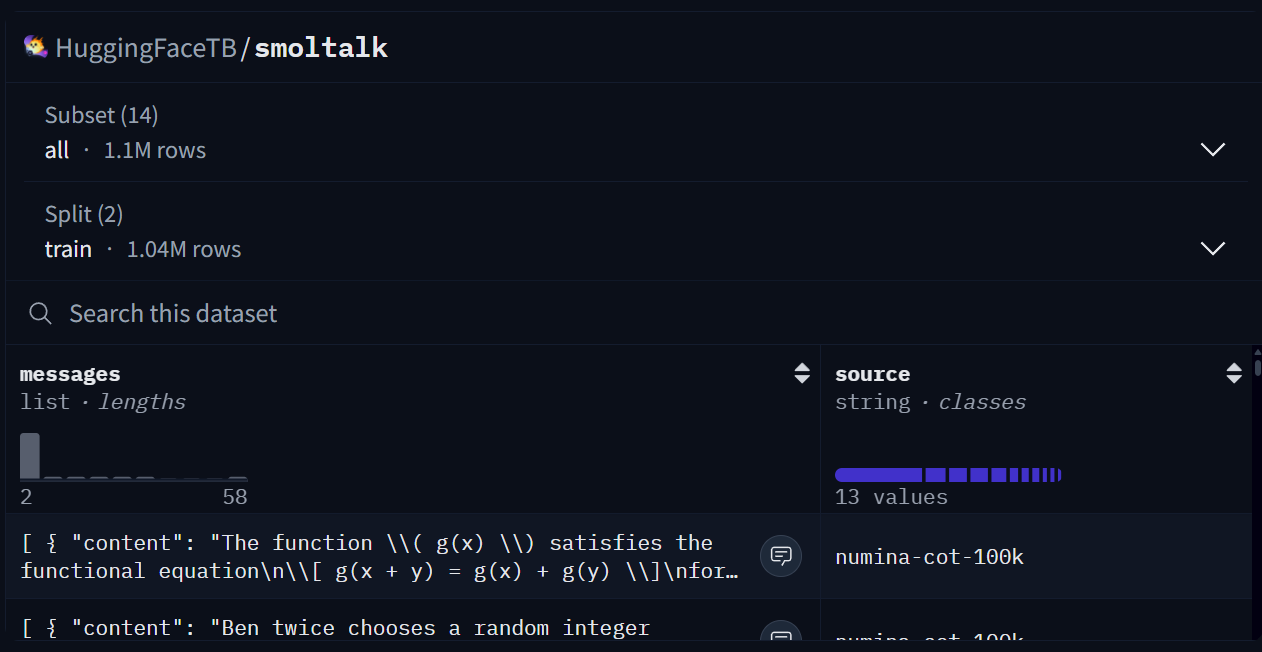

## Training Configuration

The success of your fine-tuning depends heavily on choosing the right training parameters. Let’s explore each important parameter and how to configure them effectively:

The SFTTrainer configuration requires consideration of several parameters that control the training process. Let’s explore each parameter and their purpose:

1. **Training Duration Parameters:**

    * `num_train_epochs:` Controls total training duration

    * `max_steps:` Alternative to epochs, sets maximum number of training steps

    * More epochs allow better learning but risk overfitting

---

#### `num_train_epochs` VS `max_steps` :-

**`num_train_epochs`** — Number of complete passes through your entire dataset. If set to 3 with a 1000-sample dataset, the model sees all 1000 samples 3 times (3000 total sample exposures).

**`max_steps`** — A hard cap on the number of training steps (batches processed), regardless of epochs. A "step" = one batch processed (forward pass + backward pass + weight update) — NOT one individual sample.

**Example:**

If `max_steps=500` and `per_device_train_batch_size=8`:
```
500 steps × 8 samples per batch = 4000 samples seen total
```

If your dataset has 10,000 samples and training stops after 500 steps (4000 samples), the remaining 6000 samples never get processed in that run — training halts immediately once `max_steps` is reached, regardless of how much data is left unprocessed.

**When to use which:**

- **`num_train_epochs`** → when you know your dataset size and want predictable, complete passes through the full data
- **`max_steps`** → when working with very large or streaming datasets where exact size is unknown, or when you want precise control over compute budget (e.g. "train for exactly 500 steps regardless of dataset size")

If both are set, `max_steps` usually takes priority and overrides `num_train_epochs`.

---

2. **Batch Size Parameters:**

* `per_device_train_batch_size:` Determines memory usage and training stability. [How many samples processed at once]

* `gradient_accumulation_steps:` Enables larger effective batch sizes. [Sum up gradients over multiple batches, then do one weight update]

* Larger batches provide more stable gradients but require more memory

3. **Learning Rate Parameters:**

* `learning_rate:` Controls size of weight updates

* `warmup_ratio:` Portion of training used for learning rate warmup

* Too high can cause instability, too low results in slow learning

4. **Monitoring Parameters:**

* `logging_steps:` Frequency of metric logging

* `eval_steps:` How often to evaluate on validation data

* `save_steps:` Frequency of model checkpoint saves

Start with conservative values and adjust based on monitoring:

* Begin with 1-3 epochs

* Use smaller batch sizes initially

* Monitor validation metrics closely

* Adjust learning rate if training is unstable

## Implementation with TRL

Now that we understand the key components, let’s implement the training with proper validation and monitoring. We will use the `SFTTrainer` class from the **Transformers Reinforcement Learning (`TRL`)** library, which is built on top of the `transformers` library. Here’s a complete example using the TRL library:

In [1]:
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load dataset
dataset = load_dataset("HuggingFaceTB/smoltalk", "all")   # "all" means load the combined dataset containing all 14 sub-datasets merged together (the full 1.1M rows) instead of just one specific task type.

# Configure model and tokenizer
model_name = "HuggingFaceTB/SmolLM2-135M"
model = AutoModelForCausalLM.from_pretrained(pretrained_model_name_or_path=model_name).to(
    device
)
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_name)

config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--HuggingFaceTB--SmolLM2-135M. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B /  269MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/3.66k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

**`AutoModelForCausalLM` vs `AutoConfig`**

Previously when we were training GPT-2 from scratch (Chapter 7), we used:
```python
config = AutoConfig.from_pretrained("gpt2", ...)
model = GPT2LMHeadModel(config)
```
This built a fresh model with **random weights** using GPT-2's architecture.

But here, `AutoModelForCausalLM.from_pretrained(model_name)` is different — it's the **generic Auto class for any causal (decoder-only) language model**, and `.from_pretrained()` downloads **both architecture AND pretrained weights** together.

`AutoModelForCausalLM` works with GPT-2, LLaMA, SmolLM, Mistral etc — any decoder-only model. `GPT2LMHeadModel` was specific to GPT-2 only.

---

**`AutoConfig.from_pretrained(...)` + `GPT2LMHeadModel(config)`** → architecture only, **random weights**, knows nothing, needs full training from scratch (what you did in Ch 7)

**`AutoModelForCausalLM.from_pretrained(model_name)`** → architecture AND **pretrained weights** downloaded together — the model already knows language, already has learned parameters, ready to be fine-tuned further

So in this SFT example, we're taking an **already pretrained** SmolLM2-135M model (knows language already) and about to fine-tune it further on the smoltalk dataset.

**Attention Masking in Transformers**

Attention mask exists both in encoder and decoder but they serve **different purposes**.

**Two types of masks — don't confuse them:**

**1. Padding Mask** (both encoder and decoder)

Tells model to ignore `[PAD]` tokens added to shorter sequences:

```
input:          ["I", "love", "pizza", "[PAD]"]
attention_mask: [1,    1,      1,       0     ]
# 1 = real token, 0 = ignore
```

**2. Causal Mask** (decoder only)

Blocks each token from seeing future tokens. Prevents cheating during training:

```
"I love pizza"

"I"     → sees: [I]
"love"  → sees: [I, love]          ← can't see "pizza" yet
"pizza" → sees: [I, love, pizza]
```

Encoder has NO causal mask — sees everything bidirectionally:
```
"I"     → sees: [I, love, pizza]
"love"  → sees: [I, love, pizza]
"pizza" → sees: [I, love, pizza]
```

---

**Why causal mask exists:**

During training model sees full sentence at once. Without causal mask it would cheat — peek at future tokens when predicting current one. At inference those future tokens don't exist yet, so model must learn without them.

---

**HuggingFace class → Architecture mapping:**

```
AutoModelForCausalLM     → decoder only  (GPT, LLaMA, SmolLM)
AutoModelForMaskedLM     → encoder only  (BERT, RoBERTa)
AutoModelForSeq2SeqLM    → encoder-decoder (T5, BART)
```

"Causal" in class name always means decoder only architecture.

In [6]:
import trl
print(dir(trl))

['BEMACallback', 'DPOConfig', 'DPOTrainer', 'DatasetMixtureConfig', 'GRPOConfig', 'GRPOTrainer', 'KTOConfig', 'KTOTrainer', 'LogCompletionsCallback', 'ModelConfig', 'RLOOConfig', 'RLOOTrainer', 'RewardConfig', 'RewardTrainer', 'RichProgressCallback', 'SFTConfig', 'SFTTrainer', 'ScriptArguments', 'SyncRefModelCallback', 'TrlParser', 'WeaveCallback', '__all__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_class_to_module', '_import_structure', '_modules', '_name', '_objects', 'add_response_schema', 'apply_chat_template', 'chat_template_utils', 'clone_chat_template', 'create_reference_model', 'data_utils', 'extract_prompt', 'get_dataset', 'get_peft_config', 'get_quantization_config', 'get_training_chat_template', 'init_zero_verbose', 'is_conversational', 'is_conversational_from_value', 'maybe_apply_chat_template', 'maybe_convert_to_chatml', 'maybe_extract_prompt', 'maybe_unpair_preference_dataset', 'models', 'pack_dataset', 'prepare_multimodal_

In [ ]:
from trl import SFTConfig, SFTTrainer, clone_chat_template

# Setup chat template
clone_chat_template(model, tokenizer, "HuggingFaceTB/SmolLM2-360M-Instruct")

# clone_chat_template is only copying the chat template string from that model(no weights or anything), used different model than the model checkpoint because the model checkpoint we put above is a base model that doesn't has chat template configured

# Configure trainer
training_args = SFTConfig(
    output_dir="./sft_output",
    max_steps=1000,
    per_device_train_batch_size=4,
    learning_rate=5e-5,
    logging_steps=10,
    save_steps=100,   # save checkpoint every 100 steps(batches)
    eval_strategy="steps",
    eval_steps=50,   # run evaluation every 50 steps

    # Note: by default Trainer runs evaluation on the entire eval dataset every time, so here runs evaluation on whole eval dataset every 50 steps
)

# Initialize trainer
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer,
)

# Start training
trainer.train()

It will take around an hour for tokenization and then few hours(nearly 2 to 4 hours on whole dataset) depending on your device. But here as max_steps is set to 1000 then it will take around 15-20 minutes depending on your device.

**SFT (Supervised Fine-Tuning) — What we're actually doing**

---

**Base model vs Instruction tuning:**

SmolLM2-135M is a **base model** — pretrained on general web text. It can predict next tokens and complete text but doesn't know how to follow instructions or have conversations.

`smoltalk` dataset is a **conversational/instruction dataset** — contains 1.1M examples of structured conversations between user and assistant.

So these are two completely different datasets:

```
Pretraining data  → general web text (Wikipedia, books, internet)
                    → teaches model language, facts, patterns

smoltalk data     → structured conversations, instructions, responses  
                    → teaches model to follow instructions and chat
```

---

**What SFT does:**

```
SmolLM2-135M (base, knows language but can't chat properly)
         ↓ fine-tune on smoltalk
SmolLM2-135M-Instruct (now knows how to follow instructions and have conversations)
```

This process is called **instruction tuning** — a specific type of fine-tuning that converts a base model into a chat/assistant model. Every instruct model you see (GPT, Claude, LLaMA-Instruct) went through this same process.

---

**Why SFTTrainer over regular Trainer:**

SFTTrainer handles everything automatically — tokenization, chat template formatting, packing sequences. No need to manually tokenize dataset with `.map()` like before as `SFTTrainer` handles `tokenization` automatically internally. You just pass the raw dataset and tokenizer and it tokenizes everything for you behind the scenes.

## Packing the Dataset

The SFTTrainer supports example packing to optimize training efficiency. This feature allows multiple short examples to be packed into the same input sequence, maximizing GPU utilization during training.

**Understanding Packing:**

Remember the `chunking` we did manually in chapter 7? Concatenating all texts and splitting into equal chunks so no GPU compute is wasted on padding?

This is the same concept but SFTTrainer does it automatically:

```
# without packing - short conversations padded to max length
[conversation1, PAD, PAD, PAD, PAD]  ← wasted
[conversation2, PAD, PAD, PAD, PAD]  ← wasted

# with packing - multiple short conversations packed together
[conversation1, conversation2, conversation3]  ← no waste
```

---

To enable packing, simply set `packing=True` in the `SFTConfig` constructor. When using packed datasets with `max_steps`,

be aware that you may train for more epochs than expected depending on your packing configuration meaning packing combines multiple short conversations into one sequence — so each "step" now contains more actual examples than without packing. This means you might accidentally go through the dataset multiple times (multiple epochs) before hitting max_steps=1000.

You can customize how examples are combined using a **formatting function** - particularly useful when working with datasets that have multiple fields like question-answer pairs.

For evaluation datasets, you can disable packing by setting `eval_packing=False` in the `SFTConfig`. As during evaluation you usually want clean individual examples to measure performance accurately — not packed sequences. So common practice is packing on for training (efficiency), off for evaluation (accuracy of metrics). Although evaluation weill still happen but not just on packed evaluation dataset, instead evaluation will be done on individual examples.

When packing the dataset with multiple fields, you can define a **custom formatting function** to combine the fields into a single input sequence. This function should take a list of examples and return a dictionary with the packed input sequence. 

Here’s an example of a custom formatting function:

In [ ]:
def formatting_func(example):
    text = f"### Question: {example['question']}\n ### Answer: {example['answer']}"
    return text

training_args = SFTConfig(packing=True)
trainer = SFTTrainer(
    "facebook/opt-350m",
    train_dataset=dataset,
    args=training_args,
    formatting_func=formatting_func,
)

# Note that if we don't set the other argument values in training_args and trainer then it will take default values for all others

**Formatting Function**

**Why needed:**

SFTTrainer expects text input. But some datasets have multiple fields like `question`, `answer`, `context` etc — not a single text field. Formatting function tells SFTTrainer how to combine those fields into one string.

```python
# raw example from dataset:
{
    "question": "What is Python?",
    "answer": "Python is a programming language"
}

# formatting function converts it to:
"### Question: What is Python?
 ### Answer: Python is a programming language"
```

If your dataset already has a single `text` or `messages` field — no formatting function needed, SFTTrainer handles it automatically. Only needed for datasets with custom/multiple field structures.

---

**Order of operations — formatting runs BEFORE packing:**

```
raw dataset examples
       ↓ formatting function applied to each example individually
formatted text strings
       ↓ packing combines them
[formatted_text1 + formatted_text2 + formatted_text3]
```

Formatting function does NOT take examples from the packed dataset — it processes each raw example first, then packing bundles the already-formatted strings together.

## Monitoring Training Progress

Effective monitoring is crucial for successful fine-tuning. Let’s explore what to watch for during training:

#### Understanding Loss Patterns

Training loss follows 3 phases:

1. **Initial Sharp Drop** — model is seeing new data for the first time, adjusts quickly, loss drops fast
2. **Gradual Stabilization** — model has adapted the basics, now fine-tuning smaller details, loss drops slowly
3. **Convergence** — model has learned what it can from the data, loss stops dropping and stays flat — training done

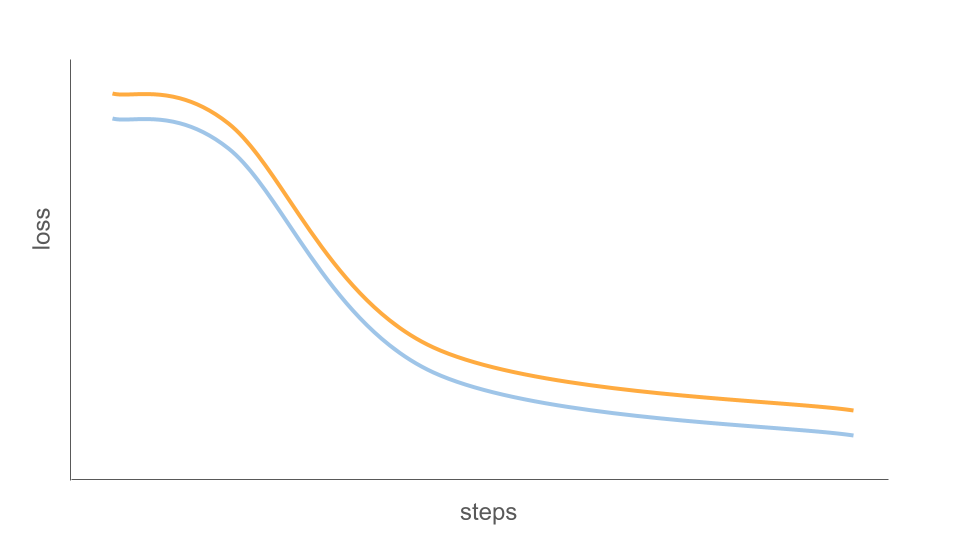

#### Metrics to Monitor

Effective monitoring involves tracking quantitative metrics, and evaluating qualitative metrics.
Available metrics are:

- **Training loss** → how much error model makes on training data, should decrease over time
- **Validation loss** → how much error on unseen data, tells if model is actually generalizing or just memorizing
- **Learning rate progression** → tracks how LR changes over training (warmup → cosine decay etc)
- **Gradient norms** → measures size of gradients, if too large = unstable training, if zero = model not learning

**Watch for these warning signs during training:**

* Validation loss increasing while training loss decreases (overfitting)

* No significant improvement in loss values (underfitting)

* Extremely low loss values (potential memorization)

* Inconsistent output formatting (template learning issues)

#### The Path to Convergence

As training progresses, the loss curve should gradually stabilize. The key indicator of healthy training is a small gap between training and validation loss, suggesting the model is learning generalizable patterns rather than memorizing specific examples. The absolute loss values will vary depending on your task and dataset.

#### Monitoring Training Progress

The graph above shows a typical training progression. Notice how both training and validation loss decrease sharply at first, then gradually level off. This pattern indicates the model is learning effectively while maintaining generalization ability.

#### Warning Signs to Watch For 

Several patterns in the loss curves can indicate potential issues. Below we illustrate common warning signs and solutions that we can consider.

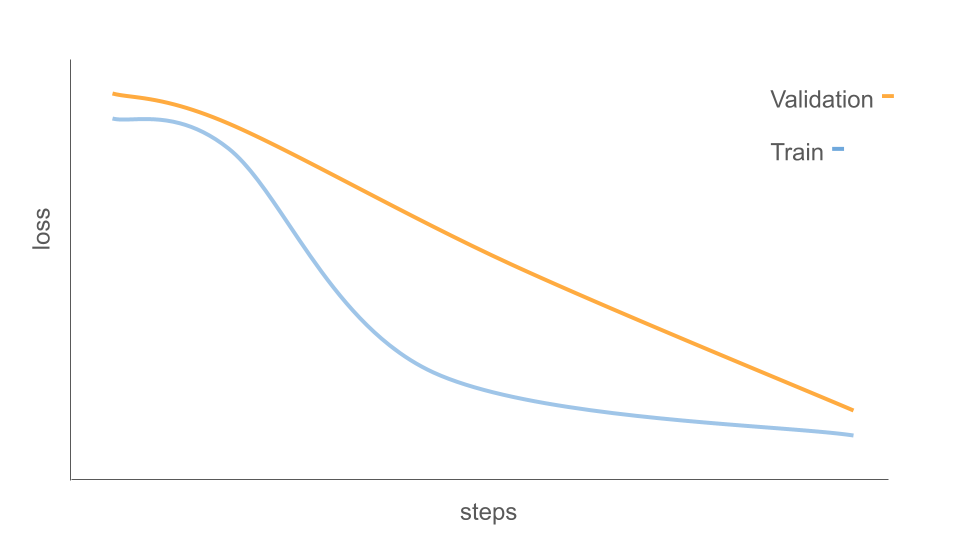

If the validation loss decreases at a significantly slower rate than training loss, your model is likely overfitting to the training data. Consider:

* Reducing the training steps

* Increasing the dataset size

* Validating dataset quality and diversity

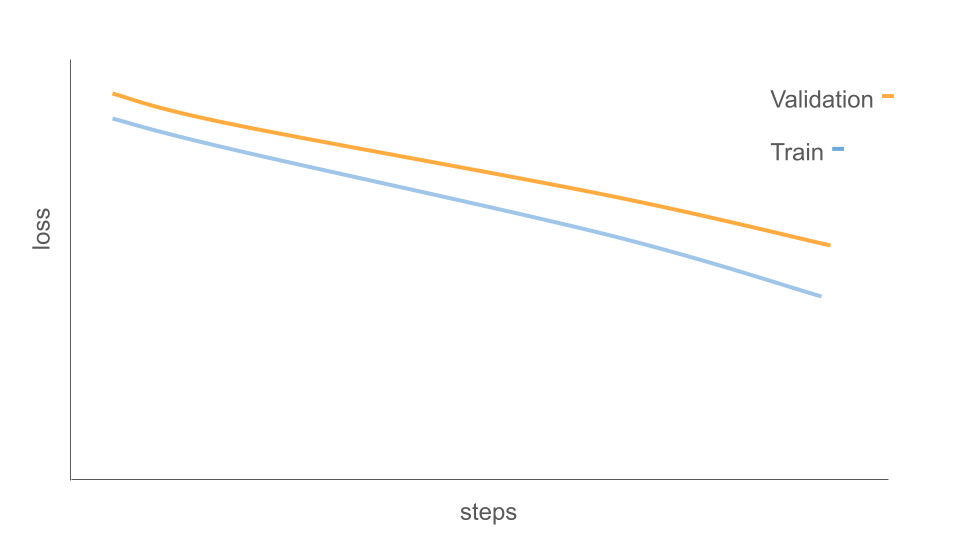

If the loss doesn’t show significant improvement, the model might be:

* Learning too slowly (try increasing the learning rate)

* Struggling with the task (check data quality and task complexity)

* Hitting architecture limitations (consider a different model)

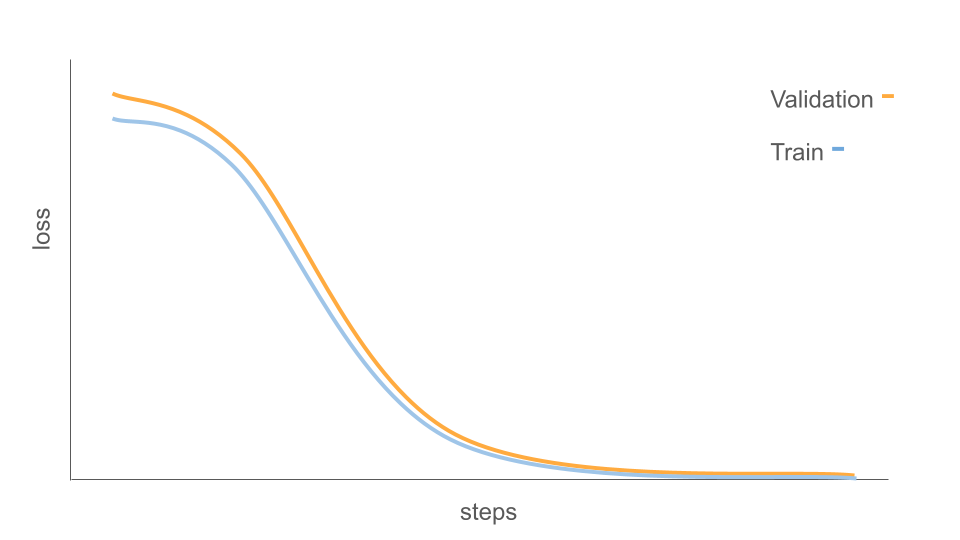

Extremely low loss values could suggest memorization rather than learning. This is particularly concerning if:

* The model performs poorly on new, similar examples

* The outputs lack diversity

* The responses are too similar to training examples

> Monitor both the loss values and the model’s actual outputs during training. Sometimes the loss can look good while the model develops unwanted behaviors. Regular qualitative evaluation of the model’s responses helps catch issues that metrics alone might miss.

We should note that the interpretation of the loss values we outline here is aimed on the most common case, and in fact, loss values can behave on various ways depending on the model, the dataset, the training parameters, etc.

If you interested in exploring more about outlined patterns, you should check out this blog post by the people at Fast AI: 

https://www.fast.ai/posts/2023-09-04-learning-jumps/

## Evaluation after SFT

In upcoming section we will learn how to evaluate the model using benchmark datasets. For now, we will focus on the qualitative evaluation of the model.

**"Qualitative evaluation"** → manually testing the model yourself — give it prompts, read the outputs, judge if they make sense. No numbers involved, just human judgment.

**After completing SFT, consider these follow-up actions:**

* Evaluate the model thoroughly on held-out test data

* Validate template adherence across various inputs

* Test domain-specific knowledge retention

* Monitor real-world performance metrics

**Document your training process:**

- **Dataset characteristics** → what dataset you used, size, type of data, any preprocessing done
- **Training parameters** → learning rate, batch size, max steps, optimizer etc
- **Performance metrics** → training loss, validation loss, any eval scores
- **Known limitations** → what the model can't do well, edge cases it fails on

Useful for future reference when you iterate on the model.

# LoRA (Low-Rank Adaptation) :-

Fine-tuning large language models is a resource intensive process. `LoRA` is a technique that allows us to fine-tune large language models with a small number of parameters. It works by adding and optimizing smaller matrices to the attention weights, typically reducing trainable parameters by about 90%.

## Understanding everything deeply:

Firstly,

#### What is "rank"?

Rank = **how many rows/columns in a matrix actually carry new/independent information**, versus how many are just copies (or scaled copies) of each other.

Let's use a tiny concrete matrix, 4 rows × 3 columns:

```
Column:      A   B   C
Row 1:       1   2   3
Row 2:       2   4   6
Row 3:       3   6   9
Row 4:       4   8   12
```

Look closely: Column B = 2 × Column A. Column C = 3 × Column A. So even though this matrix has 3 columns, **only Column A is "new" information** — B and C are just A, scaled. If you know column A, you can reconstruct the entire matrix.

That means this matrix's **rank is 1**, even though it's a 4×3 matrix (12 numbers total). It *looks* big, but it doesn't *contain* much.

**More Matrix Examples**

**Example 1:**

Take the matrix

$$
A =
\begin{bmatrix}
1 & 2 \\
2 & 4
\end{bmatrix}
$$

Look carefully.

The second row,

$$
[2 \;\; 4]
$$

is simply

$$
2 \times [1 \;\; 2]
$$

So the second row is just a copy (scaled version) of the first row.

Only **one independent row** exists.

Therefore,

$$
\boxed{\text{Rank}(A) = 1}
$$

---

**Example 2**

Consider

$$
A =
\begin{bmatrix}
1 & 3 \\
2 & 4
\end{bmatrix}
$$

Here, neither row is a multiple of the other.

Both rows contribute new information.

Therefore,

$$
\boxed{\text{Rank}(A) = 2}
$$

---

**Example 3**

Consider the matrix

$$
A =
\begin{bmatrix}
1 & 2 & 5 \\
2 & 4 & 10 \\
3 & 6 & 7
\end{bmatrix}
$$

Notice that

$$
[2 \;\; 4 \;\; 10]
=
2 \times
[1 \;\; 2 \;\; 5]
$$

So the **second row** is completely determined by the **first row** and provides **no new information**.

The independent rows are:

- Row 1
- Row 3

Therefore,

$$
\boxed{\text{Rank}(A) = 2}
$$

Even though the matrix is **\(3 \times 3\)**, it has only **2 independent rows**, so its rank is **2**.

**So "rank" = the number of truly independent directions of information in the matrix.** "Low rank" just means: this matrix, despite its size, doesn't have much independent info in it — lots of redundancy.

#### What is low-rank decomposition?

Since my matrix(that column example) above is rank 1, I can rebuild the *entire* 4×3 matrix using just **one column vector** and **one row vector** multiplied together:

```
Column vector (4×1):     Row vector (1×3):
1                         [1  2  3]
2
3
4
```

Multiply (4×1) by (1×3):

```
1     [1 2 3]     1×1 1×2 1×3     1  2  3
2  ×             = 2×1 2×2 2×3  =  2  4  6
3                   3×1 3×2 3×3     3  6  9
4                   4×1 4×2 4×3     4  8  12
```

That's exactly the original matrix! I stored **4 + 3 = 7 numbers** (the two small vectors) instead of the original **12 numbers** (4×3 matrix), and I can perfectly reconstruct it any time by multiplying them.

**That's the whole trick of low-rank decomposition: if a big matrix has low rank, you can store it as the product of two much smaller matrices instead, and multiply them back together whenever you need the full thing.** The purpose is compression — fewer numbers to store and, critically for LoRA, fewer numbers to *train*.

#### Dimension confusion 

For matrix of `4096 x 4096` and r = 8 where r is called the `LoRA rank`.

**Now the parameter count — this is separate from the output shape:**
- Matrix A has 4096 × 8 = **32,768** actual stored numbers
- Matrix B has 8 × 4096 = **32,768** actual stored numbers
- Total stored: 32,768 + 32,768 = **65,536** numbers

But when multiplied together, they *produce* a 4096×4096 = 16.7 million number matrix — you just never had to store or train 16.7 million numbers to get there. You stored 65K, and the multiplication *expands* it back up to full size only when needed.

### Understanding LoRA

One of the biggest misconceptions when learning LoRA is thinking that the two small matrices are trying to recreate the original weight matrix.

They are **not**.

Let's understand what actually happens.

---

#### Step 1: The Original Model

Suppose a neural network has a weight matrix

$$
W
$$

with shape

$$
4096 \times 4096
$$

This means the matrix contains

$$
4096 \times 4096 = 16,\!777,\!216
$$

parameters (over **16 million** weights).

For example, the matrix might look like

$$
W =
\begin{bmatrix}
1.2 & -0.3 & 0.9 & \cdots \\
0.7 & 2.1 & -1.4 & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{bmatrix}
$$

Every value inside this matrix is a learned weight. These weights contain the knowledge that the model learned during pretraining.

---

#### Step 2: What Happens During Full Fine-Tuning?

Suppose we want to fine-tune the model for a medical question-answering task.

During **full fine-tuning**, the original weights are updated.

For example,

Original weight:

$$
1.20
$$

After training:

$$
1.35
$$

Another weight,

Original:

$$
-0.50
$$

After training:

$$
-0.42
$$

This happens for **millions of weights**.

The entire weight matrix is modified.

---

#### Why Is This Expensive?

If the weight matrix contains

$$
16,\!777,\!216
$$

parameters, then training requires computing gradients, optimizer states, and updates for all of those parameters.

This consumes a large amount of GPU memory and computation.

---

#### The Core Idea of LoRA

LoRA takes a completely different approach.

Instead of modifying the original weight matrix,

$$
W
$$

LoRA **freezes** it.

A frozen matrix means its values never change during fine-tuning.

The original pretrained knowledge remains untouched.

---

#### Then How Does the Model Learn?

Instead of changing

$$
W,
$$

LoRA learns a **small correction matrix** called

$$
\Delta W
$$

The final weight used by the model becomes

$$
W' = W + \Delta W
$$

Notice something important.

The original matrix

$$
W
$$

is exactly the same as before.

The model simply adds a learned correction on top of it.

---

#### Example

Suppose the original weight matrix is

$$
W =
\begin{bmatrix}
10 & 20 \\
30 & 40
\end{bmatrix}
$$

After fine-tuning, we would ideally like the weights to become

$$
W' =
\begin{bmatrix}
10.2 & 19.8 \\
30.5 & 39.9
\end{bmatrix}
$$

The difference between the two matrices is

$$
\Delta W =
\begin{bmatrix}
0.2 & -0.2 \\
0.5 & -0.1
\end{bmatrix}
$$

Therefore,

$$
W' = W + \Delta W
$$

or

$$
\begin{bmatrix}
10 & 20 \\
30 & 40
\end{bmatrix}
+
\begin{bmatrix}
0.2 & -0.2 \\
0.5 & -0.1
\end{bmatrix}
=
\begin{bmatrix}
10.2 & 19.8 \\
30.5 & 39.9
\end{bmatrix}
$$

The original weights never changed.

We only learned the correction.

---

#### Does $\Delta W$ Have the Same Shape?

Yes.

Since

$$
W
$$

has shape

$$
4096 \times 4096,
$$

the correction matrix

$$
\Delta W
$$

must also have shape

$$
4096 \times 4096.
$$

Otherwise, the addition

$$
W + \Delta W
$$

would not be possible.

---

#### Then Why Not Learn $\Delta W$ Directly?

This is where LoRA becomes clever.

Instead of directly learning

$$
\Delta W,
$$

LoRA represents it as the product of two much smaller matrices:

$$
\boxed{\Delta W = BA}
$$

where

$$
B \in \mathbb{R}^{4096 \times r}
$$

and

$$
A \in \mathbb{R}^{r \times 4096}
$$

Here,

$$
r
$$

is called the **LoRA rank**.

---

#### Example with Rank = 8

If

$$
r = 8,
$$

then

$$
B \in \mathbb{R}^{4096 \times 8}
$$

and

$$
A \in \mathbb{R}^{8 \times 4096}
$$

Multiplying them gives

$$
(4096 \times 8)
\times
(8 \times 4096)
=
4096 \times 4096
$$

So

$$
BA
$$

has exactly the same shape as

$$
\Delta W.
$$

---

#### A Common Misconception

Many people think that

$$
BA
$$

is trying to reconstruct the original weight matrix

$$
W.
$$

This is **not true**.

The original weight matrix already exists inside the pretrained model.

There is absolutely no reason to recreate it.

Instead,

$$
BA
$$

represents only the correction

$$
\Delta W.
$$

The original model remains unchanged.

---

#### What Is Actually Being Learned?

During LoRA training,

the pretrained matrix

$$
W
$$

is frozen.

Only the matrices

$$
A
$$

and

$$
B
$$

are updated.

After training,

the correction is computed as

$$
\Delta W = BA
$$

and the final weight becomes

$$
\boxed{W_{\text{final}} = W + BA}
$$

---

#### Small Numerical Example

Suppose the original weight matrix is

$$
W =
\begin{bmatrix}
10 & 20 \\
30 & 40
\end{bmatrix}
$$

Assume LoRA learns

$$
B =
\begin{bmatrix}
1 \\
2
\end{bmatrix}
$$

and

$$
A =
\begin{bmatrix}
0.2 & -0.1
\end{bmatrix}
$$

Their product is

$$
BA =
\begin{bmatrix}
1 \\
2
\end{bmatrix}
\begin{bmatrix}
0.2 & -0.1
\end{bmatrix}
=
\begin{bmatrix}
0.2 & -0.1 \\
0.4 & -0.2
\end{bmatrix}
$$

This matrix becomes the learned correction

$$
\Delta W.
$$

Finally,

$$
W_{\text{final}}
=
W
+
BA
$$

During training, only the values inside

$$
A
$$

and

$$
B
$$

change.

The original matrix

$$
W
$$

never changes.

---

#### Then What Is the Advantage?

At first glance, it seems like nothing has been saved because

$$
BA
$$

still produces a

$$
4096 \times 4096
$$

matrix.

However, there is a crucial difference.

We **never train or store** all

$$
16,\!777,\!216
$$

entries of

$$
\Delta W.
$$

Instead, we only train the entries of

$$
A
$$

and

$$
B.
$$

For

$$
r = 8,
$$

the number of trainable parameters is

$$
4096 \times 8
+
8 \times 4096
=
65,\!536
$$

instead of

$$
16,\!777,\!216.
$$

Thus, the optimizer only updates

$$
65,\!536
$$

parameters rather than

$$
16.8
$$

million parameters.

This dramatically reduces GPU memory usage and computational cost.

---

#### Intuition

Think of the original model as a finished document.

Instead of rewriting the entire document, LoRA simply writes a small list of edits.

The original document remains unchanged.

Whenever the model is used, those edits are applied on top of the original.

Similarly,

- The pretrained model stores the original knowledge in

  $$
  W
  $$

- LoRA learns only the correction

  $$
  BA
  $$

- The model finally uses

  $$
  \boxed{W_{\text{final}} = W + BA}
  $$

This is why LoRA is often described as learning a **small patch** or **edit** to the original model rather than retraining the entire model.

#### Why r = 8 specificallY? Can we choose any?

**Yes, rank is a hyperparameter you choose** — it's not fixed by the model or the math. Common choices are 4, 8, 16, 32, sometimes up to 64 or 128. There's no "correct" value — it's a tradeoff dial you turn.

**What the tradeoff actually is:**

- **Higher rank** → A and B are bigger → more trainable parameters → more capacity to learn complex updates → but more memory/compute, and higher risk of overfitting on small datasets
- **Lower rank** → smaller A and B → fewer trainable parameters → faster/cheaper → but less expressive power, might underfit if the task needs a more complex update

Think back to my toy matrix example: I picked rank 1 because that specific matrix *happened* to be perfectly rank 1. In real fine-tuning, nobody knows in advance the "true" rank of the ideal weight update — it's not something you can measure beforehand. So rank becomes a practical guess-and-check hyperparameter, same as picking learning rate or batch size.

**Rule of thumb people use in practice:**
- Rank 8 is a very common default — often "good enough" for adapting a model to a new task/domain without needing huge capacity
- If the task is simple (e.g., adjusting tone/style) → lower rank (4–8) often works fine
- If the task is more complex (e.g., teaching new reasoning patterns, a very different domain) → people bump up to 16–32+

You'd typically just start with a reasonable default (8 or 16), train, check performance, and increase rank only if the model seems to be underfitting.

## Key advantages of LoRA

**1. Memory Efficiency:**

* Only adapter parameters are stored in GPU memory

* Base model weights remain frozen and can be loaded in lower precision

* Enables fine-tuning of large models on consumer GPUs

**2. Training Features:**

* Native PEFT/LoRA integration with minimal setup

* Support for QLoRA (Quantized LoRA) for even better memory efficiency

**3. Adapter Management:**

* Adapter weight saving during checkpoints

* Features to merge adapters back into base model

## Loading LoRA Adapters with PEFT

PEFT is a library that provides a unified interface for loading and managing PEFT methods, including LoRA. It allows you to easily load and switch between different PEFT methods, making it easier to experiment with different fine-tuning techniques.

**Understanding PEFT:**

`PEFT` stands for **Parameter-Efficient Fine-Tuning** — it's a general *category name* for a whole family of techniques whose shared goal is "fine-tune large models by training way fewer parameters than full fine-tuning." LoRA is **one specific technique** inside that category. There are others (e.g., prefix tuning, prompt tuning, adapters) — different mathematical approaches, same underlying goal.

So the hierarchy is:

```
PEFT (the category/goal: parameter-efficient fine-tuning)
 ├── LoRA (one technique — low-rank decomposition, what you just learned)
 ├── Prefix Tuning (a different technique)
 ├── Prompt Tuning (another different technique)
 └── ... a few others
```

**`peft` is *also* the name of a Python library HuggingFace built**, which happens to implement all of these techniques under one roof. That's genuinely a little confusing because the library is named exactly after the category it belongs to — same word, two meanings (the general concept vs. the specific package).

**Adapter = the small set of extra trainable weights you add to a frozen model** (in LoRA's case, that's the A and B matrices).

"LoRA adapter" just means: the trained A/B matrices for a specific task, saved separately from the base model. Since the base model stays frozen and untouched, you can:

- Keep the adapter as a small separate file (megabytes, not gigabytes)
- Swap adapters in/out on the same base model for different tasks
- Share/download just the adapter instead of the whole fine-tuned model

Adapters can be loaded onto a pretrained model with `load_adapter()`, which is useful for trying out different adapters whose weights aren’t merged. Set the active adapter weights with the `set_adapter()` function. To return the base model, you could use `unload()` to unload all of the LoRA modules. This makes it easy to switch between different task-specific weights.

In [ ]:
from peft import PeftModel, PeftConfig

config = PeftConfig.from_pretrained("ybelkada/opt-350m-lora")
model = AutoModelForCausalLM.from_pretrained(config.base_model_name_or_path)
lora_model = PeftModel.from_pretrained(model, "ybelkada/opt-350m-lora")

#### Let's understand the above code :-

```python
config = PeftConfig.from_pretrained("ybelkada/opt-350m-lora")
```

This downloads just the **settings/metadata** for a LoRA adapter that someone already trained and uploaded to HuggingFace Hub. `config` tells you things like: what base model this adapter was trained on top of, what rank was used, which layers it targets, etc. It's not weights yet — just the recipe/blueprint.

**`What is ybelkada/opt-350m-lora`** 

It is an adapter (just the small A/B matrices) - saved as its own repo on HuggingFace Hub. What's actually inside that repo is just the small trained LoRA weights + the config, not a full set of billions of parameters.

---

```python
model = AutoModelForCausalLM.from_pretrained(config.base_model_name_or_path)
```
This loads the **original frozen base model** (e.g., plain OPT-350M) — the one the adapter was trained against. `config.base_model_name_or_path` is just reading that info out of the config from step 1, so you load the *correct* base model rather than guessing.

At this point: `model` = plain vanilla base model, no LoRA applied yet.

---

```python
lora_model = PeftModel.from_pretrained(model, "ybelkada/opt-350m-lora")
```
*This* is the step that actually attaches the adapter. It takes your plain `model` and wraps it with the pretrained LoRA A/B matrices downloaded from `"ybelkada/opt-350m-lora"`. Now `lora_model` = base model + LoRA adapter applied.

Note that we didn't load a model on which LoRA was applied, we actually applied the adapter on that model.

---

Normally *you'd* train your own LoRA adapter on a base model. But this particular code example is showing the *other* use case: **loading someone else's already-trained adapter** and applying it to the same base model they trained it on.

Below we will train our own LoRA adapter on a base model.

## Fine-tune LLM using trl and the SFTTrainer with LoRA

The `SFTTrainer` from `trl` provides integration with LoRA adapters through the `PEFT` library. This means that we can fine-tune a model in the same way as we did with SFT, but use LoRA to reduce the number of parameters we need to train.

We’ll use the `LoRAConfig` class from PEFT in our example. The setup requires just a few configuration steps:

* Define the LoRA configuration (rank, alpha, dropout)

* Create the SFTTrainer with PEFT config

* Train and save the adapter weights

### LoRA Configuration

Let’s walk through the LoRA configuration and key parameters.

#### 1) `r` (rank):

Dimension of the low-rank matrices used for weight updates. Typically between 4-32. Lower values provide more compression but potentially less expressiveness.

#### 2) `lora_alpha`:

**Background: what LoRA is doing:**

LoRA freezes the original model weights `W` and learns a small correction on top of them, using two small matrices `A` and `B`:

```
Output = (W × input) + (A × B × input)
```

`W` is never modified — it stays exactly as pretrained. `A × B` produces a small learned correction that gets added on top, every forward pass.

---

**Step 1: The raw A×B output has a side effect (before any scaling):**

Matrix multiplication works by **summing multiple multiplied pairs together**. The number of pairs summed equals the **rank** (the shared middle dimension between A and B).

**Example — rank = 2:**
```
A = [3, 5]
B = [2
     4]

A × B = (3×2) + (5×4) = 6 + 20 = 26
```

**Example — rank = 4** (same size individual numbers, just more of them):
```
A = [3, 5, 2, 4]
B = [2
     4
     1
     3]

A × B = (3×2) + (5×4) + (2×1) + (4×3) = 6 + 20 + 2 + 12 = 40
```

**The side effect:** going from rank 2 → rank 4 made the output jump from 26 → 40, even though the individual numbers were similarly sized. This happened purely because **more terms got summed** — not because anything was "learned better." 

**Problem this causes:** if you experiment with different ranks (e.g., trying rank=4, then rank=16, then rank=32 to see what works best), the raw A×B output size shifts around just from this side effect. That makes it hard to tell whether a change in model behavior came from rank giving the adapter more *learning capacity*, or just from the output *accidentally being bigger*.

---

**Step 2: Dividing by rank cancels this side effect:**

To stop rank from accidentally affecting output size, LoRA divides the raw A×B output by rank:

```
Corrected output = (A × B) / rank
```

**Applying it to the example above:**
- Rank = 2 → 26 / 2 = **13**
- Rank = 4 → 40 / 4 = **10**

Now both outputs land in a similar, comparable range (~10–13) instead of one being much bigger than the other just because it summed more terms.

**Result:** changing rank now only changes the adapter's *capacity* to learn complex patterns — it no longer also secretly changes the *size* of the update being applied to the model. Rank and update-strength are now decoupled.

---

**Step 3: Multiplying by alpha — the deliberate strength control:**

Dividing by rank gives a stable, predictable baseline — but that baseline is just "neutral." It doesn't tell you how strongly you *actually want* the adapter to affect the model's behavior. That's a separate, intentional decision — which is what `alpha` is for.

```
Final correction = (alpha / rank) × (A × B)
```

**Continuing the example** (corrected output = 10, from rank = 4):

| alpha | alpha/rank | Final correction | Meaning |
|---|---|---|---|
| alpha = 4 (= rank) | 1 | 10 × 1 = **10** | No extra boost — use the neutral baseline as-is |
| alpha = 8 (2× rank) | 2 | 10 × 2 = **20** | Deliberately stronger adaptation |
| alpha = 2 (0.5× rank) | 0.5 | 10 × 0.5 = **5** | Deliberately gentler, more conservative adaptation |

`lora_alpha` is typically set to **~2× the rank** as a common default starting point (not a hard rule).

---

**Summary — the full sequence:**

1. **Raw A×B** naturally produces bigger numbers as rank increases, purely as a side effect of summing more terms (not better learning).
2. **Dividing by rank** cancels that side effect, giving a stable baseline regardless of which rank is chosen.
3. **Multiplying by alpha** is then a deliberate, separate choice — controlling *how strongly* the adapter's (now-stabilized) correction affects the model, independent of whatever rank was picked.

This is why rank and alpha are two independent hyperparameters: **rank = adapter's learning capacity**, **alpha = how strongly that learned correction is allowed to influence the model.**

#### 3) `lora_dropout`:

It is a dropout probability for LoRA layers(just means the A and B matrices - calling them "layers" is just terminology, they're small trainable linear layers inserted into the model, technically). Typically `0.05-0.1`.

**`lora_dropout`:** Dropout is a standard neural net technique — during training, it randomly "turns off" (zeroes out) a percentage of values, forcing the model to not over-rely on any specific few numbers. Applied here, it randomly zeroes out some of the A/B computations during training.

**Why:** Since A and B are small, they can sometimes overfit — basically memorize your specific training examples too closely instead of learning general patterns. Dropout (e.g.,  5-10% of values randomly dropped each step) makes that harder, forcing more robust learning.

#### 4) `bias`:

**Bias = an extra number added after the main weight multiplication.** In a normal neural net layer: `output = (W × input) + bias`. That `bias` is a separate small set of trainable numbers, one per output — separate from the big weight matrix itself.

**This LoRA parameter decides whether those bias terms also get trained, or stay frozen:**

- **`"none"`** — biases stay frozen (untouched, same as original model). Only A and B get trained. Most common choice — fewer trainable parameters = more memory efficient, which is the whole point of LoRA anyway.
- **`"all"`** — every bias in the entire model becomes trainable, not just ones near LoRA layers.
- **`"lora_only"`** — only the biases belonging to the layers where LoRA was applied become trainable; everything else stays frozen.

Since biases are a tiny fraction of a model's total parameters, training them barely adds cost — but `"none"` is still preferred by default simply to keep things maximally lean and avoid unnecessary changes to the base model's original behavior.

#### 5) `target_modules`:

**"Module" here just means a specific layer/component inside the model** — like a named building block. A transformer block, for instance, is made of several modules: query projection, key projection, value projection, output projection, feed-forward layers, etc. Each of these is technically a separate weight matrix doing a specific job. In code, they usually have names like `q_proj`, `k_proj`, `v_proj`, `o_proj`.

**`target_modules` decides which of these specific weight matrices get a LoRA adapter attached, vs. which stay completely untouched (fully frozen, no adapter at all).**

Recall: LoRA doesn't automatically apply itself to the *whole* model — you choose exactly which weight matrices get an A/B pair added next to them. Everything else in the model stays 100% frozen with zero adapter involvement.

**Options:**
- `"all-linear"` — attach LoRA adapters to every linear layer in the model
- Specific names like `"q_proj,v_proj"` — only attach LoRA to the query and value projection matrices inside attention (a very common choice — the original LoRA paper found targeting just these two often works nearly as well as targeting everything)

**Tradeoff:** more targeted modules = more places the model can adapt = better potential performance, but also more A/B matrices = more trainable parameters = more memory, working against LoRA's whole "efficient" purpose.

**q_proj/v_proj/k_proj/o_proj** Short version: attention has 4 projections (Q, K, V, O). Research found adapting just Q and V tends to capture most of the benefit, so it's a common efficient default.

**But AXB has same shape as original matrix eg. [(original)4096 x 4096(AxB) so doesn't all weights gonna be updated? so what does targeting specific module means?**

You're right that A×B produces a matrix the *same shape* as the original (4096×4096) — but "same shape" doesn't mean "every single number gets meaningfully changed."

**Here's the key idea: which module gets *targeted at all* is a completely separate decision from what happens *inside* that module once targeted.**

- `target_modules` decides: does q_proj get an adapter, or does it stay 100% frozen with zero A/B involvement at all?
- If q_proj **is** targeted → yes, then A×B (shape 4096×4096) gets added to q_proj's entire weight matrix — every number in q_proj's matrix does get a small correction added to it, technically touching all 4096×4096 positions.
- If q_proj is **not** targeted (say you only chose `"q_proj,v_proj"` and q_proj wasn't in that list, hypothetically) → q_proj stays completely frozen, zero changes, not even a tiny one.

**So `target_modules` is really answering: "out of all the different weight matrices in the model (q_proj, k_proj, v_proj, o_proj, feed-forward layers, etc.), which ones even get an adapter attached to them at all?"**

It's not about partially touching one matrix — it's about choosing *which whole matrices* get an adapter versus staying completely untouched. Once a matrix is chosen, yes, A×B (same shape) adds a correction across that entire matrix — but that correction tends to be small and learned (thanks to rank/alpha scaling), not a destructive full overwrite.

> When implementing PEFT methods, start with small rank values (4-8) for LoRA and monitor training loss. Use validation sets to prevent overfitting and compare results with full fine-tuning baselines when possible. The effectiveness of different methods can vary by task, so experimentation is key.

## Using TRL with PEFT

`PEFT` methods can be combined with `TRL` for fine-tuning to reduce **training memory(memory needed for training - training happens only on 67K numbers not on whole 67M numbers so training memory reduces)** requirements. We can pass the `LoraConfig` to the model when loading it.

**Why we are using `TRL/SFTTrainer` and `PEFT/LoRA` together:**

- **`SFTTrainer` by itself (no LoRA)** = trains *all* the model's original parameters. Every single weight in the model gets gradients and gets updated. This is full fine-tuning, just using the SFT-style training loop/data format.

- **`SFTTrainer` + LoRA together** = the model's original parameters are **frozen** (no gradients, untouched), and only the newly-added A/B adapter parameters get trained. `SFTTrainer` is still running the same *kind* of training loop (SFT-style, same data formatting, same loss calculation) — but now it's only updating the small adapter sitting on top, not the whole model underneath.

so LoRA doesn't change *what* SFTTrainer is doing conceptually (still supervised fine-tuning on your task-specific data) — it changes *which parameters are actually eligible to receive updates* during that process. Without LoRA, "eligible" = everything. With LoRA, "eligible" = just the small adapter.


**But WAIT! how lora will save memory if original matrix shape is 4096x4096 and AXB is 4096x4096 as well! and 4096x4096 has total 16.7M numbers so doesn't AXB has 16.7M numbers too? And will it not take same time,computation,memory as the original model took?**

Good — let's isolate exactly where your reasoning is right, and where the missing piece is.

**You are 100% correct about one thing:** the raw computation of multiplying A×B to produce a 4096×4096 result does take real time and real compute — roughly comparable to a 4096×4096 matrix multiply. No argument there, you're right.

Let's understand with illustration:

#### Matrix A

Size = **4096 × 8**

Number of elements:

```
4096 × 8 = 32,768
```

So A contains **32,768 numbers**.

---

#### Matrix B

Size = **8 × 4096**

Number of elements:

```
8 × 4096 = 32,768
```

So B also contains **32,768 numbers**.

---

**Total parameters stored in LoRA**

Since LoRA stores **both** A and B:

```
32,768 + 32,768
= 65,536 numbers
≈ 65K numbers
```

This is where people say **"LoRA only trains ~65K parameters"**.

---

**But what about A × B?**

When you multiply

```
(4096 × 8)
×
(8 × 4096)
```

the result has shape

```
4096 × 4096
```

That matrix contains

```
4096 × 4096
= 16,777,216 numbers
≈ 16.8 million numbers
```

So **A × B does NOT have 65K numbers**.

It has **16.8 million numbers**.

---

**Think of it like this**

```
A
4096 × 8
= 32,768 numbers

B
8 × 4096
= 32,768 numbers

Stored numbers
= 65,536
```

But after multiplication:

```
A × B

4096 × 4096

= 16,777,216 numbers ~ 16.7M
```

---

**But here's what you're missing: training a matrix needs way more than "compute the numbers once."**

Let's separate two totally different things people often blur together:

**1. Using a matrix (forward pass) — just compute output = matrix × input, once.**
This is relatively cheap and fast, whether it's the original W or a freshly computed A×B.

**2. Training a matrix — this needs 4 things stored simultaneously, not just 1:**
- The weight values themselves
- Gradients (how much to change each weight) — same size as the weights
- Optimizer's "momentum" tracker — same size as the weights  
- Optimizer's "variance" tracker — same size as the weights

**So if a matrix is trainable, you need memory for ALL FOUR of those — roughly 4x the raw parameter count.**

**Only A and B are being trained.** So only A and B need all 4 things (values + gradients + 2 optimizer trackers). And A/B are tiny (65K numbers total) — so 4x of *that* is still small (~260K), compared to 4x of the full 16.7M W would've been (~67M).

**You're right that A × B, once computed, produces a 4096×4096 result — 16.7M numbers.** No disagreement there.

**But here's the key distinction: those 16.7M numbers are not stored anywhere as their own independent, trainable values. They're freshly recalculated, every single time, from A and B.**

Let's separate two very different things:

**"How many numbers exist in the final multiplied-out result"** → 16.7M (you're right)

**"How many numbers does the computer actually need to store and update during training"** → only what's in A (4096×8 = 32,768) and B (8×4096 = 32,768) = 65,536 total

**Why is that enough?** Because the 4096×4096 result is *fully determined* by A and B — it's not extra independent information sitting somewhere, it's just what you get *when* you multiply A and B together. It's like a formula's output vs. the formula's inputs. If I tell you "this number is always `x × y`", I don't need to separately store the answer for every possible x,y combination — I just need to store x and y, and compute the answer fresh whenever I need it.

**Applying that to training specifically:** during training, gradient descent doesn't ask "what should each of these 16.7M output numbers individually become?" It asks "what should A's 32,768 numbers become, and what should B's 32,768 numbers become, such that when multiplied together, they produce a *good* 4096×4096 correction?"

So gradients get computed **with respect to A and B's actual stored numbers** (65K total), not with respect to 16.7M independent slots. Same for optimizer momentum/variance trackers — they track A's and B's values, not a separately-stored 16.7M-number result.

In [ ]:
# --- Using stuffs of previous model (model, tokenizer, dataset setup) ---

from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from trl import SFTConfig, SFTTrainer, setup_chat_format
from peft import LoraConfig
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "HuggingFaceTB/SmolLM2-135M"
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Set up chat format (adds chat template + special tokens)
model, tokenizer = setup_chat_format(model=model, tokenizer=tokenizer)

finetune_name = "SmolLM2-FT-LoRA"

# Load dataset
dataset = load_dataset(path="HuggingFaceTB/smoltalk", name="everyday-conversations")

# --- Training args ---

max_seq_length = 1024  # cap on token length per training example

args = SFTConfig(
    output_dir="./sft_lora_output",
    max_steps=1000,
    per_device_train_batch_size=4,   # lower this (e.g. 2) if you hit VRAM OOM(Out Of Memory) on your 6GB GPU
    learning_rate=5e-5,
    logging_steps=10,
    save_steps=100,
    eval_strategy="steps",
    eval_steps=50,
    max_seq_length=max_seq_length,
)

In [ ]:
from peft import LoraConfig

# TODO: Configure LoRA parameters
# r: rank dimension for LoRA update matrices (smaller = more compression)
rank_dimension = 6
# lora_alpha: scaling factor for LoRA layers (higher = stronger adaptation)
lora_alpha = 8   # generally 2xrank works best but not necessarily 2xrank
# lora_dropout: dropout probability for LoRA layers (helps prevent overfitting)
lora_dropout = 0.05

peft_config = LoraConfig(
    r=rank_dimension, 
    lora_alpha=lora_alpha,  
    lora_dropout=lora_dropout,  
    bias="none",  
    target_modules="all-linear",  # Which modules to apply LoRA to
    task_type="CAUSAL_LM",  # Task type for model architecture, CASUAL_LM = casual language modeling, so it knows how to correctly set things up internally (e.g., how outputs are shaped, how the adapter should be applied given the model's structure etc)
)

We will also need to define the `SFTTrainer` with the LoRA configuration.

In [ ]:
# Create SFTTrainer with LoRA configuration
trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=dataset["train"],
    peft_config=peft_config,  # LoRA configuration, this is what actually applies LoRA
    max_seq_length=max_seq_length,  # Maximum sequence length
    processing_class=tokenizer,   # note that newer trl uses processing_class instead of tokenizer=
)

trainer.train()

**Where would the adapter actually be saved?** 

After training, you'd call `trainer.save_model("./some_folder")` (same pattern as the 11.3 notebook's `trainer.save_model(f"./{finetune_name}")`) — that writes the adapter's files (A/B weights + config) to that folder.

In [ ]:
# Save the trained LoRA adapter (and tokenizer)

trainer.save_model("./lora_adapters")

**What's actually in the saved "adapter"?**

Yes — it's essentially your trained A and B matrices (for every module you targeted, e.g., all the `q_proj`, `v_proj`, etc. across every layer), plus a small config file recording the settings used (rank, alpha, target_modules, etc., basically your `LoraConfig` values) so PEFT knows how to correctly re-attach them to a base model later.

## Merging LoRA Adapters

After training with LoRA, you might want to merge the adapter weights back into the base model for easier deployment. This creates a single model with the combined weights, eliminating the need to load adapters separately during inference.

Recall from your earlier notes: during training/inference, LoRA computes `output = (W × input) + (A × B × input)` — two separate computations added together, every forward pass.

**Merging** means: instead of keeping W and the adapter (A, B) as separate pieces that get combined at runtime, you compute `A × B` once, add it directly into W, and save that as a single new weight matrix — `W_new = W + (alpha/rank) × (A × B)`.

**Why bother, if it works fine unmerged?**
- Unmerged: every forward pass does *two* computations (original path + adapter path) and adds them — slightly more compute/latency at inference time, plus you need to keep the adapter as a separate file/object alongside the base model.
- Merged: you get *one* clean model, one weight file, no extra adapter-path computation at inference — behaves and deploys exactly like any normal fine-tuned model, with zero runtime overhead from LoRA's math.

**The tradeoff:** once merged, you lose the "swap adapters easily" flexibility — you can't just detach this adapter and attach a different one anymore, since it's now baked permanently into the weights. So people merge when they're done experimenting and want a final, deployable model; they keep adapters separate while still experimenting or if they need to support multiple task-specific adapters on one base model.

The merging process requires attention to memory management and precision. Since you’ll need to load both the base model and adapter weights simultaneously, ensure sufficient GPU/CPU memory is available. Using device_map="auto" in transformers will find the correct device for the model based on your hardware.

Merging doesn't inherently need *more* memory than the final result should — The memory concern here is about something more specific: a **temporary, one-time bottleneck during the merge process itself**, not an ongoing cost.

**Here's the actual reason:** to *do* the merge, you need to have loaded into memory **at the same time**:
1. The full base model W (all its original parameters)
2. The adapter A and B (small, negligible)

That's basically just... loading the base model, which you'd need to do anyway to use it at all — not really an *extra* memory cost specific to merging.

**Where it can actually bite you:** for genuinely huge models (like the course's earlier GPT-3 175B example), just loading the base model itself already requires serious GPU/CPU memory, regardless of LoRA. If your hardware is already close to its limit just holding the base model, then the merge operation (which needs the base model loaded, plus does an addition operation across all those weights) can be the thing that tips you over available memory — not because merging is expensive by nature, but because you're now actively computing on top of an already large loaded model, momentarily needing a bit of extra headroom for the addition operation and the new output tensor.

So, merging doesn't create new *permanent* memory overhead compared to a normal model of that size — the final merged model is exactly as big as the base model always was. The caution is about the **temporary moment of doing the merge**, where you need the (potentially large) base model plus a little working memory simultaneously, same as you'd need for *any* operation on a large model — it's not an added cost unique to LoRA, just a reminder that merging isn't "free" in the sense of requiring zero memory, especially relevant for people working with very large models where every bit of headroom matters.

Maintain consistent precision (e.g., float16) throughout the process, matching the precision used during training and saving the merged model in the same format for deployment.

### Merging Implementation

After training a LoRA adapter, you can merge the adapter weights back into the base model. Here’s how to do it:

In [ ]:
import torch
from transformers import AutoModelForCausalLM
from peft import PeftModel

# 1. Load the base model
base_model = AutoModelForCausalLM.from_pretrained(
    model_name, torch_dtype=torch.float16, device_map="auto"   # torch_dtype: controls the precision (how many bits are used to store each number) the model's weights are loaded in
)

# 2. Load the PEFT model with adapter
peft_model = PeftModel.from_pretrained(
    base_model, "path/to/adapter", torch_dtype=torch.float16
)

# 3. Merge adapter weights with base model
merged_model = peft_model.merge_and_unload()

**`merge_and_unload()` — what does "unload" mean here?**

Two things happen in this one call:
1. **Merge:** computes `W_new = W + (alpha/rank)×(A×B)` for every targeted matrix, producing the combined weights.
2. **Unload:** removes/discards the now-redundant(no longer usefull) separate LoRA adapter modules (the standalone A, B objects PEFT had wrapped around the model) — since their information is now baked into `W_new`, there's no reason to keep them around as separate objects taking up extra memory/structure anymore.

In [ ]:
# Save both model and tokenizer

merged_model.save_pretrained("./merged_models/my_first_merged_model")
tokenizer.save_pretrained("./merged_models/my_first_merged_model")

# Evaluation :-

With a finetuned model through either `SFT` or `LoRA SFT`, we should evaluate it on standard benchmarks.

A **benchmark** is a standardized test dataset/collection of datasets (fixed questions/tasks with known correct answers) used to measure and compare model performance in a consistent, repeatable way.

Instead of just eyeballing a model's outputs and guessing if it's "good," a benchmark gives you a fixed set of problems everyone agrees on, runs the model through them, and produces a score — so you can compare different models fairly (same test, same conditions) or track whether your own model actually improved after fine-tuning.

Example you've likely seen referenced: GLUE (**a collection of language understanding tasks[here task is referring to dataset]**) — a benchmark, not a dataset you fine-tune on for a real product, but a common yardstick researchers use to say "model A scores 85 on GLUE, model B scores 90."

`GLUE` isn't one single task, it's a **bundle of several small test datasets**, each testing a different language skill (e.g., one checks if two sentences mean the same thing, another checks sentiment, another checks grammatical correctness). Each of those individual mini-tests is a "task" and GLUE = the whole bundle of them together, used as one combined benchmark.

So:

`benchmark` = test dataset(s) used to score a model.
`GLUE` = a specific benchmark made of multiple smaller test datasets bundled together, rather than just one.

As machine learning engineers you should maintain a suite of relevant evaluations for your targeted domain of interest. In this page, we will look at some of the most common benchmarks and how to use them to evaluate your model. We’ll also look at how to create custom benchmarks for your specific use case.

### Automatic 

Automatic benchmarks serve as standardized tools for evaluating language models across different tasks and capabilities. While they provide a useful starting point for understanding model performance, it’s important to recognize that they represent only one piece of a comprehensive evaluation strategy.

#### Understanding Automatic Benchmarks

**Automatic benchmarks** = ready-made test datasets with fixed questions and fixed correct answers, plus a scoring method — so a model can be evaluated automatically (no human needed to judge each answer).

**Scoring Method :-**

It is the specific rule/formula used to compare the model's answer against the correct answer and turn that into a number.

No — the model isn't told any scoring rules or asked to "follow" anything special. It just does what it normally does: given a question, it generates its best answer, exactly like normal use. **Scoring happens *after*, separately** — comparing what the model said vs. what the correct answer was.

**Two common ways this comparison/scoring works:**

**1. Exact match (for simple cases, e.g. multiple choice):**
Question has one clearly correct answer (like "A", "B", "C", "D"). Model picks one. Either it matches the correct answer or it doesn't. Score = percentage of questions gotten exactly right.

**2. Similarity-based scoring (for open-ended text answers):**
Model generates a free-text answer (not exact multiple choice). Since wording can vary while still being correct ("cause damage to cells" vs "damages cellular structures" — same meaning, different words), scoring can't just check exact text match. Instead, some scoring method measures how *close* the model's answer is to the reference correct answer — e.g., how many overlapping words/phrases, or more advanced methods comparing meaning.

**Why "automatic" matters:** since the correct answers are already known, you can run a model through thousands of test questions and get a score instantly — no manual review needed. That's what makes it fast and consistent across different models (everyone gets tested the same way).

**The catch:** scoring well on these benchmarks doesn't guarantee the model will actually be good at your specific real-world task. Benchmarks test general, standardized skills — your actual use case might be narrower or different in ways the benchmark doesn't capture. So a high benchmark score is a useful signal, but not a guarantee of real-world performance.

**So isn't my model supposed to evaluat on same domain specific test dataset that it was trained on?**

For example, if out model was pre-trained specifically for medical stuffs train dataset:

Good question — let's clear up the mismatch you're sensing, because you've actually spotted the exact issue the course text was warning about.

**Automatic benchmarks are usually *not* your specific dataset.** They're generic, pre-made test sets built by researchers to test general skills (reasoning, grammar, factual knowledge, math, etc.) — not tailored to your medical Q&A task at all. So if you fine-tuned a model specifically on medical questions, running it on a generic benchmark (like GLUE) tests *unrelated* general skills, not how good it is at medicine specifically.

**That's literally what the course's warning meant:** "benchmark performance doesn't always translate directly to real-world effectiveness. A model that excels at academic benchmarks may still struggle with specific domain applications." — a model could score well on generic benchmarks while still being mediocre at your actual medical use case, because the benchmark never tested that.

**So for your medical example specifically:** if you wanted to properly evaluate a medical fine-tuned model, you'd want either a *medical-specific* benchmark (some do exist, domain-specific ones), or you'd hold out some of your own medical Q&A data (not used in training) and test the model against that — rather than relying on a generic, unrelated benchmark to tell you if it's good at medicine.

### General Knowledge Benchmarks

**MMLU** (Massive Multitask Language Understanding) — tests a model across 57 different subjects (science, humanities, etc.) to check broad general knowledge. Good for measuring wide coverage, but since it's broad, it doesn't test deep, specialized expertise in any one specific domain.

**TruthfulQA** — checks whether a model tends to repeat common myths/misconceptions instead of giving accurate answers. Useful for catching that specific failure mode, but doesn't catch every possible type of misinformation a model could produce.

> Note that all of these (GLUE, MMLU, TruthfulQA) are examples of automatic benchmarks — pre-made datasets with known correct answers, scored automatically, no human judging each response. "Automatic benchmark" is the general category; GLUE, MMLU, TruthfulQA are specific individual benchmarks within that category, each testing different things.

### Reasoning Benchmarks

**BBH (Big Bench Hard)** and **GSM8K** focus on complex reasoning tasks. BBH tests logical thinking and planning, while GSM8K specifically targets mathematical problem-solving. These benchmarks help assess analytical capabilities but may not capture the nuanced reasoning required in real-world scenarios.

### Language Understanding

**HELM** — a framework that evaluates a model across *many* different aspects at once (not just one skill), like commonsense reasoning, world knowledge, general reasoning, etc. — giving a broader, "holistic" picture of a model's overall capabilities rather than a single narrow score.

**Limitation:** even with that broad coverage, it still may not capture how a model handles real, natural back-and-forth conversation, or specialized/technical vocabulary specific to a particular field.

Note that,

**HELM is technically a framework**, not a single benchmark itself — it's a *system/methodology* for running many different benchmarks together and evaluating a model across all of them at once, then presenting the combined results in a structured way. It doesn't have its own one fixed test set the way MMLU or TruthfulQA does — instead, it *orchestrates* a whole collection of existing benchmarks under one consistent evaluation process.

### Domain-Specific Benchmarks

Let’s look at a few benchmarks that focus on specific domains like math, coding, and chat.

The **MATH** benchmark is another important evaluation tool for mathematical reasoning. It consists of 12,500 problems from mathematics competitions, covering algebra, geometry, number theory, counting, probability, and more. What makes MATH particularly challenging is that it requires multi-step reasoning, formal mathematical notation understanding, and the ability to generate step-by-step solutions. Unlike simpler arithmetic tasks, MATH problems often demand sophisticated problem-solving strategies and mathematical concept applications.

The **HumanEval** Benchmark is a coding-focused evaluation dataset consisting of 164 programming problems. The benchmark tests a model’s ability to generate functionally correct Python code that solves the given programming tasks. What makes HumanEval particularly valuable is that it evaluates both code generation capabilities and functional correctness through actual test case execution, rather than just superficial similarity to reference solutions. The problems range from basic string manipulation to more complex algorithms and data structures.

**Alpaca Eval** is an automated evaluation framework designed to assess the quality of instruction-following language models. It uses GPT-4 as a judge to evaluate model outputs across various dimensions including helpfulness, honesty, and harmlessness. The framework includes a dataset of 805 carefully curated prompts and can evaluate responses against multiple reference models like Claude, GPT-4, and others. What makes Alpaca Eval particularly useful is its ability to provide consistent, scalable evaluations without requiring human annotators, while still capturing nuanced aspects of model performance that traditional metrics might miss.

## Alternative Evaluation Approaches

Many organizations have developed alternative evaluation methods to address the limitations of standard benchmarks:

### LLM-as-Judge

Using one language model to evaluate another’s outputs has become increasingly popular. This approach can provide more nuanced feedback than traditional metrics, though it comes with its own biases and limitations.

### Evaluation Arenas

Evaluation arenas like **Chatbot Arena** offer a unique approach to LLM assessment through crowdsourced feedback. In these platforms, users engage in anonymous “battles” between two LLMs, asking questions and voting on which model provides better responses. This approach captures real-world usage patterns and preferences through diverse, challenging questions, with studies showing strong agreement between crowd-sourced votes and expert evaluations. While powerful, these platforms have limitations including potential user base bias, skewed prompt distributions, and a primary focus on helpfulness rather than safety considerations.

### Custom Benchmark Suites

Instead of relying only on generic public benchmarks (GLUE, MMLU, etc.), companies often build their **own** benchmarks specific to their actual product/use case — e.g., testing exactly the kind of questions or scenarios their model will really face in production, or domain-specific knowledge relevant to their field. This gives more realistic, relevant evaluation than generic benchmarks alone, since it's testing what actually matters for their specific application rather than broad general skills.

### Custom Evaluation

While standard benchmarks provide a useful baseline, they shouldn’t be your only evaluation method. Here’s how to develop a more comprehensive approach:

1. Start with relevant standard benchmarks to establish a baseline and enable comparison with other models.

2. Identify the specific requirements and challenges of your use case. What tasks will your model actually perform? What kinds of errors would be most problematic?

3. Develop custom evaluation datasets that reflect your actual use case. This might include:

    * Real user queries from your domain
    * Common edge cases you’ve encountered
    * Examples of particularly challenging scenarios

3. Consider implementing a multi-layered evaluation strategy:

    - **Automated metrics** – fast, automatic scoring using benchmarks/formulas, no human involved, good for quick sanity checks.
    - **Human evaluation** – real people review outputs to judge quality/nuance that automatic scoring can miss.
    - **Domain expert review** – specialists in the relevant field (e.g., doctors for medical answers) check outputs for accuracy specific to that domain.
    - **A/B testing in controlled environments** – comparing two versions of a model (or model vs. no model) on real users/scenarios to see which actually performs better in practice.

## Implementing Custom Evaluations

In this section, we will implement evaluation for our finetuned model. We can use `lighteval` to evaluate our finetuned model on standard benchmarks, which contains a wide range of tasks built into the library. We just need to define the tasks we want to evaluate and the parameters for the evaluation.

**LightEval** tasks are defined using a specific format:

> {suite}|{task}|{num_few_shot}|{auto_reduce}

**`suite`** — which overall benchmark you're running (e.g., MMLU or TruthfulQA — think of it as picking *which* benchmark collection you want to evaluate on).

**`task`** — since benchmarks like MMLU are made up of many subject-specific mini-tests (recall: 57 subjects), this specifies *which one* you're running — e.g., `abstract_algebra` picks just that one subject's questions, not all 57.

**`num_few_shot`** — how many example question-answer pairs you show the model *before* asking it the real test question, as a hint/demo of the expected format. `0` means zero-shot (no examples given, just straight into the real question). Higher numbers (e.g., 5) mean you show the model 5 solved examples first, which often improves its performance since it now has a pattern to follow.

**`auto_reduce`** — a safety setting: prompts have a maximum length limit (context window). If adding your chosen number of few-shot examples makes the prompt too long, this setting (`1` = on) automatically trims down the number of examples included until it fits, rather than the whole thing failing/erroring out. `0` = off, meaning it won't auto-adjust — you'd need to manually fix the count if it's too long.

Example: `"mmlu|abstract_algebra|0|0"` evaluates on MMLU’s abstract algebra task with zero-shot inference.

## Example Evaluation Pipeline

Let’s set up an evaluation pipeline for our finetuned model. We will evaluate the model on set of sub tasks that relate to the domain of medicine.

Here’s a complete example of evaluating on automatic benchmarks relevant to one specific domain using Lighteval with the VLLM backend:

```bash
lighteval accelerate \
    "pretrained=your-model-name" \
    "mmlu|anatomy|0|0" \
    "mmlu|high_school_biology|0|0" \
    "mmlu|high_school_chemistry|0|0" \
    "mmlu|professional_medicine|0|0" \
    max_samples 40    # only test on 40 questions per subject, instead of the full set (faster, quick check)
    batch_size 1      # how many questions get processed at once (1 = one at a time; higher = faster but more memory needed)
    output_path "./results"   # folder where the evaluation results/scores get saved
    save_generations true   # also save the model's actual generated answers, not just the final scores (useful for manually inspecting what it said wrong)
```

**Breaking down the structure:**

- `lighteval accelerate` — runs LightEval using Accelerate (for handling model loading/hardware)

- `"pretrained=your-model-name"` — which model to evaluate (placeholder — you'd put your actual model name/path here)

- Each `"mmlu|subject|0|0"` line — picks one specific MMLU subject to test on. The two `0`s correspond to `num_few_shot` and `auto_reduce` (both set to 0 here — zero-shot, no auto-reduction) — the same parameters you just learned.

Results are displayed in a tabular format showing:

|                  Task                  |Version|Metric|Value |   |Stderr|
|----------------------------------------|------:|------|-----:|---|-----:|
|all                                     |       |acc   |0.3333|±  |0.1169|
|leaderboard:mmlu:_average:5             |       |acc   |0.3400|±  |0.1121|
|leaderboard:mmlu:anatomy:5              |      0|acc   |0.4500|±  |0.1141|
|leaderboard:mmlu:high_school_biology:5  |      0|acc   |0.1500|±  |0.0819|

**`Stderr`** = standard error — a statistics term measuring how uncertain/reliable that accuracy number is, based on how few questions were tested (recall `--max_samples 40` — small sample size means more uncertainty in the score). Roughly: a smaller stderr means you can trust the accuracy number more; a bigger stderr means the result could easily shift if you tested different/more questions.

**The `±`** — this is standard scientific notation for "the true value is probably within this range." So `0.4500 ± 0.1141` for anatomy means: the model's real accuracy is likely somewhere between roughly `0.336` and `0.564` — the `0.45` is your best estimate, but with only a small number of test questions, there's meaningful uncertainty around that exact number. Bigger stderr = wider, less confident range.

**Only accuracy shown here:** yes, for MMLU specifically — since it's multiple-choice style questions (pick the correct option), "accuracy" (percentage of questions answered correctly) is really the only metric that makes sense; there's no ambiguity to measure via other metrics like similarity scoring (that's more relevant for open-ended text-generation benchmarks, not multiple-choice ones like MMLU).

Lighteval also include a python API for more detailed evaluation tasks, which is useful for manipulating the results in a more flexible way. Check out the Lighteval documentation for more information.